In [77]:
import numpy as np #Подключим нужные библиотеки и посмотрим как выглядит датасет
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
data = pd.read_csv('dopPS_2026.07.01_06.54.44.csv', skiprows=15)
#В csv описано, что означает каждый столбик, поэтому пропускаем эти строчки
data.sample(50)

,pl_name,hostname,sy_snum,soltype,pl_controv_flag,st_spectype
17148,OGLE-2015-BLG-1771L b,OGLE-2015-BLG-1771L,1,Published Confirmed,0,NaN
16028,Kepler-85 c,Kepler-85,1,Published Confirmed,0,NaN
14540,Kepler-59 b,Kepler-59,1,Published Confirmed,0,NaN
9917,Kepler-1886 b,Kepler-1886,1,Published Confirmed,0,NaN
7170,Kepler-1255 b,Kepler-1255,1,Published Confirmed,0,NaN
12473,Kepler-335 c,Kepler-335,1,Published Confirmed,0,NaN
1050,HAT-P-2 b,HAT-P-2,1,Published Confirmed,0,NaN
2807,HD 215152 e,HD 215152,1,Published Confirmed,0,NaN
4890,K2-413 b,K2-413,1,Published Confirmed,0,NaN
10018,Kepler-1920 b,Kepler-1920,1,Published Confirmed,0,NaN


In [64]:
data.info()
data_copy=data.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20292 entries, 0 to 20291
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   pl_name          20292 non-null  object
 1   hostname         20292 non-null  object
 2   sy_snum          20292 non-null  int64 
 3   soltype          20292 non-null  object
 4   pl_controv_flag  20292 non-null  int64 
 5   st_spectype      3006 non-null   object
dtypes: int64(2), object(4)
memory usage: 951.3+ KB


In [65]:
result_df = (
    data_copy.groupby('pl_name')
    .agg({
        'sy_snum': 'first',       # Оставляем только одно упоминание
        'hostname': 'first',
        'st_spectype': 'first'
    })
    .reset_index()
)

result_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   pl_name      6240 non-null   object
 1   sy_snum      6240 non-null   int64 
 2   hostname     6240 non-null   object
 3   st_spectype  1935 non-null   object
dtypes: int64(1), object(3)
memory usage: 195.1+ KB


In [69]:
result1_df = result_df.dropna()
result1_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1935 entries, 0 to 6239
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   pl_name      1935 non-null   object
 1   sy_snum      1935 non-null   int64 
 2   hostname     1935 non-null   object
 3   st_spectype  1935 non-null   object
dtypes: int64(1), object(3)
memory usage: 75.6+ KB


In [70]:
result1_df.to_csv('dataS.csv')

In [73]:
dataS=result1_df.copy()

In [74]:
dataRM = pd.read_csv('dataRM.csv', skiprows=0)

In [76]:
merged_df = dataRM.merge(dataS, on='pl_name', how='inner')
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 869 entries, 0 to 868
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       869 non-null    int64  
 1   pl_name          869 non-null    object 
 2   sy_snum_x        869 non-null    int64  
 3   discoverymethod  869 non-null    object 
 4   disc_year        869 non-null    float64
 5   pl_radj          869 non-null    float64
 6   pl_bmassj        869 non-null    float64
 7   sy_snum_y        869 non-null    int64  
 8   hostname         869 non-null    object 
 9   st_spectype      869 non-null    object 
dtypes: float64(3), int64(3), object(4)
memory usage: 74.7+ KB


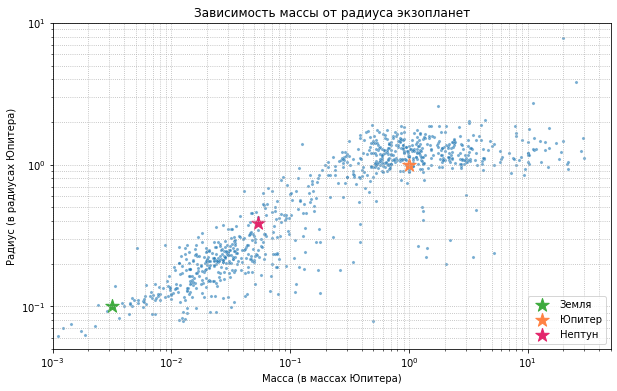

In [78]:
solar_system = {
    'Земля': {'mass': 0.00315, 'radius': 0.101, 'color': '#3caa3c'}, #Цвет влюбленной жабы
    'Юпитер': {'mass': 1.0, 'radius': 1.0, 'color': '#ff8243'}, #Цвет Манго-танго
    'Нептун': {'mass': 0.054, 'radius': 0.388, 'color': '#e3256b'} #Цвет суеты
}
clean_plot = merged_df.copy()
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clean_plot,
    x='pl_bmassj', y='pl_radj',
    alpha=0.6, s=10
)
for planet, params in solar_system.items():
    plt.scatter(params['mass'], params['radius'],
               color=params['color'], marker='*', s=200, label=planet)

plt.xscale('log'); plt.yscale('log')
plt.xlim(1e-3, 50)
plt.ylim(5e-2, 10)
plt.grid(True, which='both', ls=':')
plt.title('Зависимость массы от радиуса экзопланет')
plt.xlabel('Масса (в массах Юпитера)')
plt.ylabel('Радиус (в радиусах Юпитера)')
plt.legend(loc='lower right', framealpha=0.8)
plt.show()

In [79]:
merged_df

,Unnamed: 0,pl_name,sy_snum_x,discoverymethod,disc_year,pl_radj,pl_bmassj,sy_snum_y,hostname,st_spectype
0,0,1RXS J160929.1-210524 b,1,Imaging,2008.0,1.664000,8.000000,1,1RXS J160929.1-210524,K7 V
1,1,2MASS J02192210-3925225 b,1,Imaging,2015.0,1.440000,13.900000,1,2MASS J02192210-3925225,M6
2,2,2MASS J0249-0557 c,2,Imaging,2018.0,1.550000,11.380000,2,2MASS J0249-0557 A,M6 V
3,3,2MASS J12073346-3932539 b,1,Imaging,2004.0,1.400000,5.200000,1,2MASS J12073346-3932539,M8
4,4,55 Cnc e,2,Radial Velocity,2004.0,0.172495,0.025422,2,55 Cnc,G8 V
...,...,...,...,...,...,...,...,...,...,...
864,1672,XO-5 b,1,Transit,2008.0,1.109000,1.084000,1,XO-5,G8 V
865,1673,XO-6 b,1,Transit,2016.0,2.070000,4.400000,1,XO-6,F5
866,1674,XO-7 b,1,Transit,2019.0,1.371500,0.709500,1,XO-7,G0 V
867,1678,kap And b,1,Imaging,2012.0,1.420000,17.300000,1,kap And,B9 IVn
